In [1]:
# ==========================================
# Import Library
# ==========================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import (
    MobileNetV2,
    EfficientNetB0
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [15]:
# ==========================================
# Upload Dataset
# ==========================================

from google.colab import files
import zipfile
import os

print("Silakan upload file archive.zip")

uploaded = files.upload()

Silakan upload file archive.zip


Saving archive (2).zip to archive (2) (2).zip


In [20]:
import shutil
import os

# Hapus folder lama jika ada
for folder in ["train", "val", "test"]:
    if os.path.exists(f"/content/{folder}"):
        shutil.rmtree(f"/content/{folder}")

print("Folder lama berhasil dihapus.")

Folder lama berhasil dihapus.


In [21]:
# ==========================================
# Ekstrak Dataset
# ==========================================

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset berhasil diekstrak.")

Dataset berhasil diekstrak.


In [22]:
# ==========================================
# Menentukan Lokasi Dataset
# ==========================================

train_dir = "/content/train"
valid_dir = "/content/val"
test_dir  = "/content/test"

print("Training   :", train_dir)
print("Validation :", valid_dir)
print("Testing    :", test_dir)

Training   : /content/train
Validation : /content/val
Testing    : /content/test


In [23]:
# ==========================================
# Memastikan Dataset
# ==========================================

import os

print("Isi folder /content")

print(os.listdir("/content"))

Isi folder /content
['.config', 'test', 'train', 'archive (2).zip', 'val', 'archive (2) (2).zip', 'archive (2) (1).zip', 'sample_data']


In [24]:
# ==========================================
# Struktur Dataset
# ==========================================

for folder in [train_dir, valid_dir, test_dir]:

    print(f"\nFolder : {os.path.basename(folder)}")

    for kelas in sorted(os.listdir(folder)):
        print(f" ├── {kelas}")


Folder : train
 ├── healthy
 ├── leaf curl
 ├── leaf spot

Folder : val
 ├── healthy
 ├── leaf curl
 ├── leaf spot

Folder : test
 ├── healthy
 ├── leaf curl
 ├── leaf spot


In [25]:
# ==========================================
# Menampilkan Nama Kelas
# ==========================================

classes = sorted(os.listdir(train_dir))

print("="*40)

print("Jumlah Kelas :", len(classes))

print("Nama Kelas")

for i, kelas in enumerate(classes, start=1):
    print(f"{i}. {kelas}")

print("="*40)

Jumlah Kelas : 3
Nama Kelas
1. healthy
2. leaf curl
3. leaf spot


In [26]:
# ==========================================
# Menghitung Jumlah Data Setiap Kelas
# ==========================================

import pandas as pd

dataset_info = []

for kelas in classes:

    train_total = len(os.listdir(os.path.join(train_dir, kelas)))
    val_total   = len(os.listdir(os.path.join(valid_dir, kelas)))
    test_total  = len(os.listdir(os.path.join(test_dir, kelas)))

    dataset_info.append({
        "Kelas": kelas,
        "Train": train_total,
        "Validation": val_total,
        "Test": test_total,
        "Total": train_total + val_total + test_total
    })

df_dataset = pd.DataFrame(dataset_info)

df_dataset

,Kelas,Train,Validation,Test,Total
0,healthy,80,10,10,100
1,leaf curl,80,10,10,100
2,leaf spot,80,10,10,100


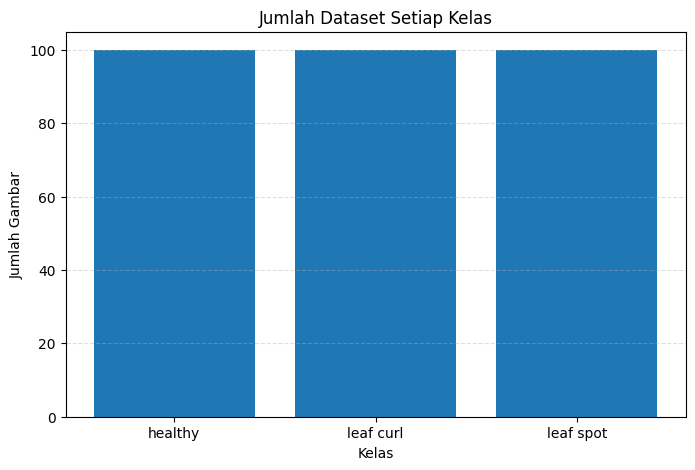

In [27]:
# ==========================================
# Visualisasi Jumlah Dataset
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df_dataset["Kelas"], df_dataset["Total"])

plt.title("Jumlah Dataset Setiap Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

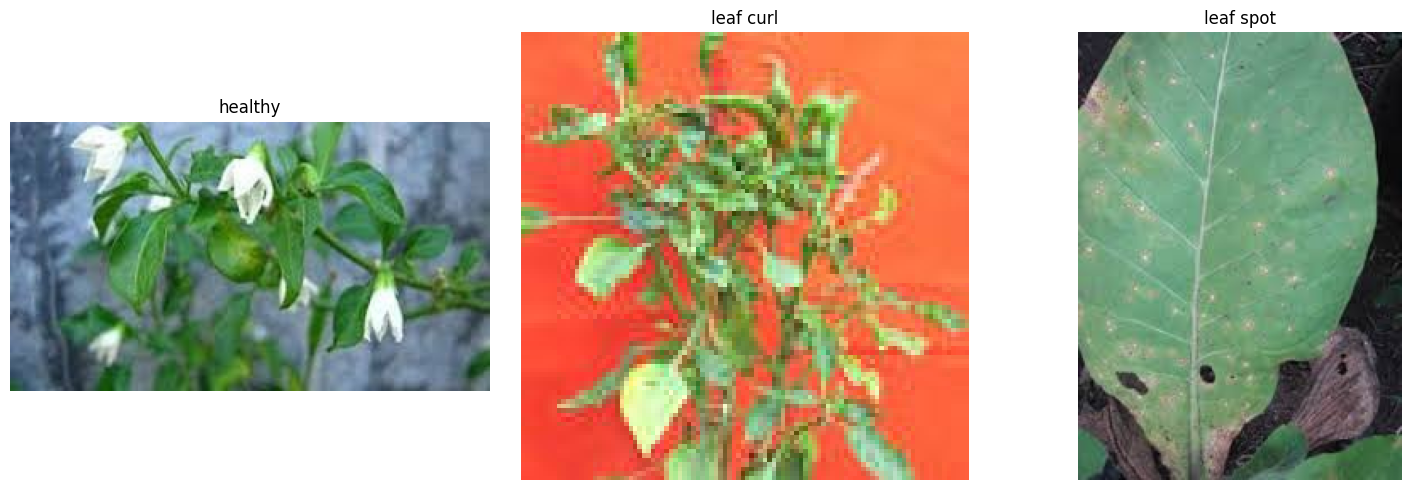

In [28]:
# ==========================================
# Menampilkan Contoh Gambar Dataset
# ==========================================

import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(15,5))

for i, kelas in enumerate(classes):

    folder = os.path.join(train_dir, kelas)

    gambar = random.choice(os.listdir(folder))

    img = load_img(os.path.join(folder, gambar))

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()

plt.show()

In [29]:
# ==========================================
# Informasi Ukuran Gambar
# ==========================================

from PIL import Image

for kelas in classes:

    folder = os.path.join(train_dir, kelas)

    gambar = random.choice(os.listdir(folder))

    img = Image.open(os.path.join(folder, gambar))

    print("="*45)
    print("Kelas :", kelas)
    print("Ukuran :", img.size)
    print("Mode :", img.mode)

Kelas : healthy
Ukuran : (272, 185)
Mode : RGB
Kelas : leaf curl
Ukuran : (271, 186)
Mode : RGB
Kelas : leaf spot
Ukuran : (275, 183)
Mode : RGB


In [30]:
# ==========================================
# Data Preparation
# Menentukan Parameter
# ==========================================

# Ukuran gambar
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32

# Jumlah epoch
EPOCHS = 20

print("Ukuran Gambar :", IMG_SIZE)
print("Batch Size    :", BATCH_SIZE)
print("Epoch         :", EPOCHS)

Ukuran Gambar : (224, 224)
Batch Size    : 32
Epoch         : 20


In [31]:
# ==========================================
# Data Augmentation
# ==========================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [32]:
# ==========================================
# Load Dataset
# ==========================================

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 240 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


In [33]:
# ==========================================
# Informasi Dataset
# ==========================================

print("="*45)

print("Jumlah Data Training   :", train_data.samples)
print("Jumlah Data Validation :", valid_data.samples)
print("Jumlah Data Testing    :", test_data.samples)

print("="*45)

print("Jumlah Kelas :", train_data.num_classes)

print("="*45)

print("Nama Kelas")

for nama, indeks in train_data.class_indices.items():
    print(f"{indeks} : {nama}")

Jumlah Data Training   : 240
Jumlah Data Validation : 30
Jumlah Data Testing    : 30
Jumlah Kelas : 3
Nama Kelas
0 : healthy
1 : leaf curl
2 : leaf spot


In [34]:
# ==========================================
# Shape Dataset
# ==========================================

images, labels = next(train_data)

print("Shape Gambar :", images.shape)
print("Shape Label  :", labels.shape)

Shape Gambar : (32, 224, 224, 3)
Shape Label  : (32, 3)


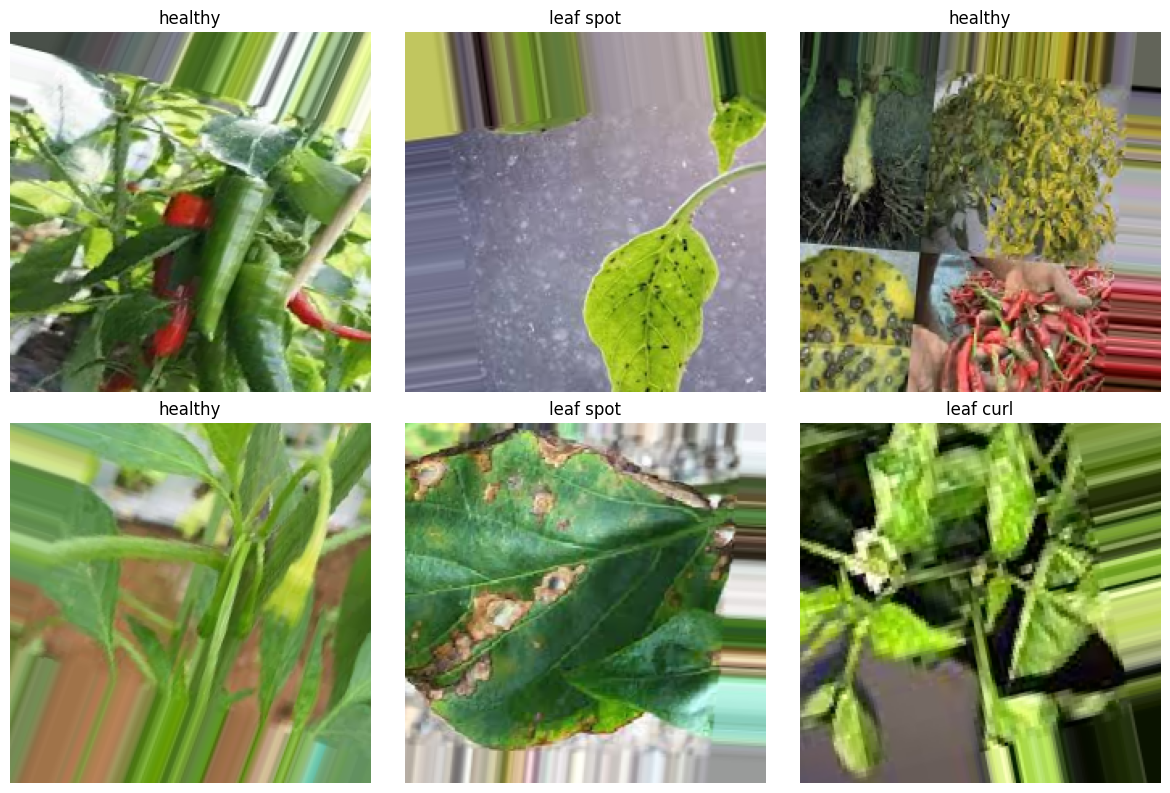

In [35]:
# ==========================================
# Contoh Batch Data
# ==========================================

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# Callback Training
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "mobilenetv2_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [37]:
# ==========================================
# Model 1 : MobileNetV2
# ==========================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load model dasar
base_model1 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layer
base_model1.trainable = False

# Menambahkan layer klasifikasi
x = base_model1.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

model1 = Model(
    inputs=base_model1.input,
    outputs=output
)

model1.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
# ==========================================
# Compile Model MobileNetV2
# ==========================================

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
# ==========================================
# Training MobileNetV2
# ==========================================

history1 = model1.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2597 - loss: 1.6742
Epoch 1: val_accuracy improved from None to 0.46667, saving model to mobilenetv2_best.keras

Epoch 1: finished saving model to mobilenetv2_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.3250 - loss: 1.5714 - val_accuracy: 0.4667 - val_loss: 1.1160
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.5694 - loss: 0.9357
Epoch 2: val_accuracy improved from 0.46667 to 0.66667, saving model to mobilenetv2_best.keras

Epoch 2: finished saving model to mobilenetv2_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.5667 - loss: 0.9464 - val_accuracy: 0.6667 - val_loss: 0.8368
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6702 - loss: 0.7357
Epoch 3: val_accuracy improved from 0.66667 to 0.70000, saving model to mobilenetv2_best.keras

Epoch 3: finished saving model to mobilenetv2_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 419ms/step - accuracy: 0.6833 - loss: 0

In [40]:
# ==========================================
# Evaluasi MobileNetV2
# ==========================================

loss1, acc1 = model1.evaluate(test_data)

print("="*40)
print("MobileNetV2")
print("="*40)
print(f"Test Accuracy : {acc1:.4f}")
print(f"Test Loss     : {loss1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9333 - loss: 0.2491
MobileNetV2
Test Accuracy : 0.9333
Test Loss     : 0.2491


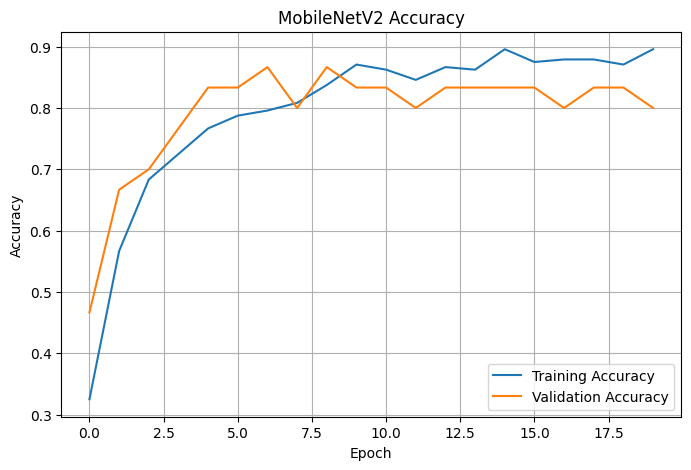

In [41]:
# ==========================================
# Grafik Accuracy MobileNetV2
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

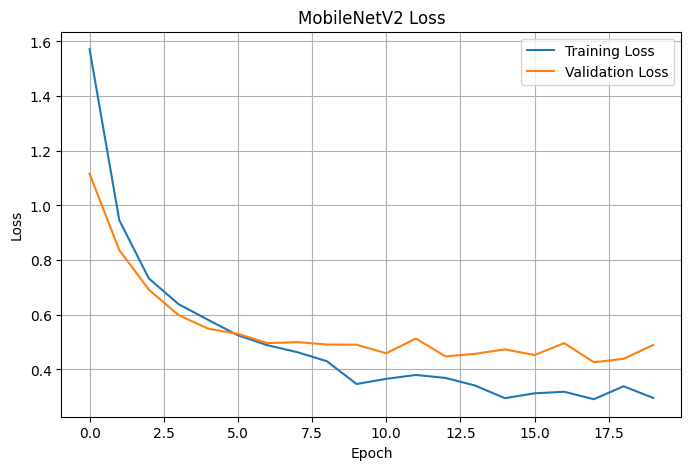

In [42]:
# ==========================================
# Grafik Loss MobileNetV2
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [43]:
# ==========================================
# Callback Training EfficientNetB0
# ==========================================

checkpoint2 = ModelCheckpoint(
    "efficientnetb0_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [44]:
# ==========================================
# Model 2 : EfficientNetB0
# ==========================================

from tensorflow.keras.applications import EfficientNetB0

# Load model dasar
base_model2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layer
base_model2.trainable = False

# Menambahkan layer klasifikasi
x = base_model2.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

model2 = Model(
    inputs=base_model2.input,
    outputs=output
)

model2.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [45]:
# ==========================================
# Compile Model EfficientNetB0
# ==========================================

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
# ==========================================
# Training EfficientNetB0
# ==========================================

history2 = model2.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint2]
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2666 - loss: 1.1561
Epoch 1: val_accuracy improved from None to 0.33333, saving model to efficientnetb0_best.keras

Epoch 1: finished saving model to efficientnetb0_best.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 73s 7s/step - accuracy: 0.2750 - loss: 1.1416 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.2759 - loss: 1.1259
Epoch 2: val_accuracy did not improve from 0.33333
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 527ms/step - accuracy: 0.2958 - loss: 1.1221 - val_accuracy: 0.3333 - val_loss: 1.1045
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.3608 - loss: 1.0908
Epoch 3: val_accuracy did not improve from 0.33333
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 757ms/step - accuracy: 0.3417 - loss: 1.1057 - val_accuracy: 0.3333 - val_loss: 1.1070
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.4425 - loss: 1.0869
Epoch 4: val_accuracy did not improve from 0.33333
8/8 ━━━━━━━━━━━

In [47]:
# ==========================================
# Evaluasi EfficientNetB0
# ==========================================

loss2, acc2 = model2.evaluate(test_data)

print("="*40)
print("EfficientNetB0")
print("="*40)
print(f"Test Accuracy : {acc2:.4f}")
print(f"Test Loss     : {loss2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.3333 - loss: 1.0983
EfficientNetB0
Test Accuracy : 0.3333
Test Loss     : 1.0983


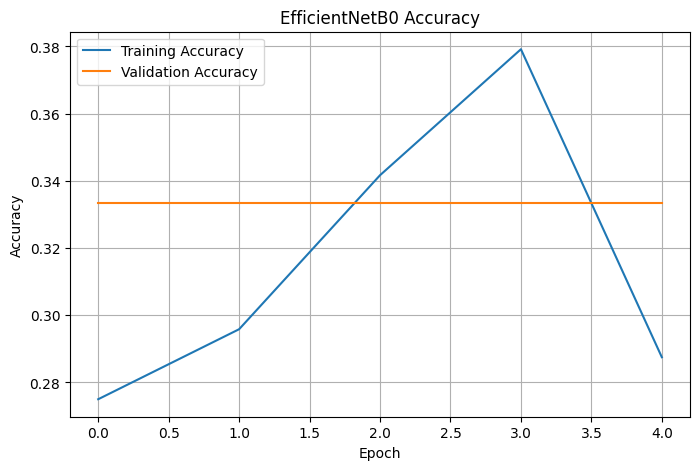

In [48]:
# ==========================================
# Grafik Accuracy EfficientNetB0
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

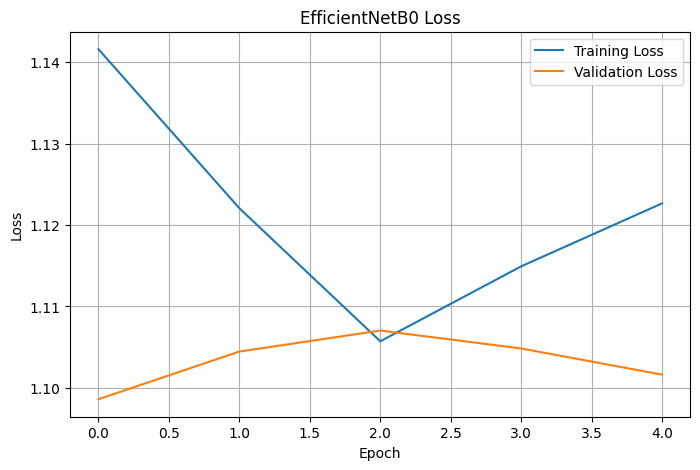

In [49]:
# ==========================================
# Grafik Loss EfficientNetB0
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [50]:
# ==========================================
# Prediksi MobileNetV2
# ==========================================

import numpy as np

pred1 = model1.predict(test_data)

y_pred1 = np.argmax(pred1, axis=1)

y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


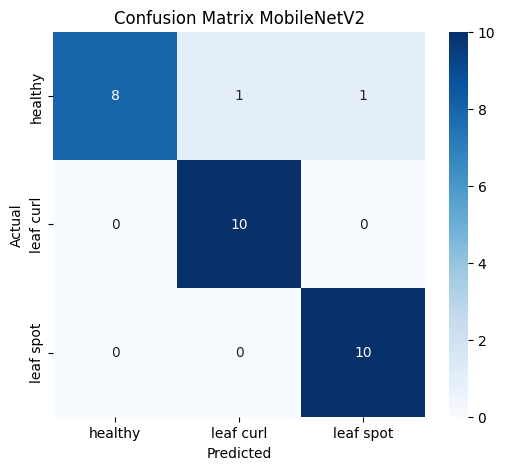

In [51]:
# ==========================================
# Confusion Matrix MobileNetV2
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm1 = confusion_matrix(y_true, y_pred1)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# ==========================================
# Classification Report MobileNetV2
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred1,
    target_names=class_names
))

              precision    recall  f1-score   support

     healthy       1.00      0.80      0.89        10
   leaf curl       0.91      1.00      0.95        10
   leaf spot       0.91      1.00      0.95        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [53]:
# ==========================================
# Prediksi EfficientNetB0
# ==========================================

pred2 = model2.predict(test_data)

y_pred2 = np.argmax(pred2, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


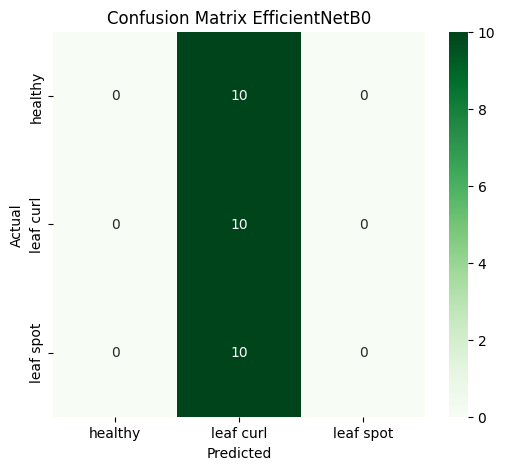

In [54]:
# ==========================================
# Confusion Matrix EfficientNetB0
# ==========================================

cm2 = confusion_matrix(y_true, y_pred2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix EfficientNetB0")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [55]:
# ==========================================
# Classification Report EfficientNetB0
# ==========================================

print(classification_report(
    y_true,
    y_pred2,
    target_names=class_names
))

              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00        10
   leaf curl       0.33      1.00      0.50        10
   leaf spot       0.00      0.00      0.00        10

    accuracy                           0.33        30
   macro avg       0.11      0.33      0.17        30
weighted avg       0.11      0.33      0.17        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
# ==========================================
# Perbandingan Model
# ==========================================

import pandas as pd

hasil = pd.DataFrame({
    "Model": [
        "MobileNetV2",
        "EfficientNetB0"
    ],
    "Accuracy": [
        acc1,
        acc2
    ],
    "Loss": [
        loss1,
        loss2
    ]
})

hasil

,Model,Accuracy,Loss
0,MobileNetV2,0.933333,0.249090
1,EfficientNetB0,0.333333,1.098258


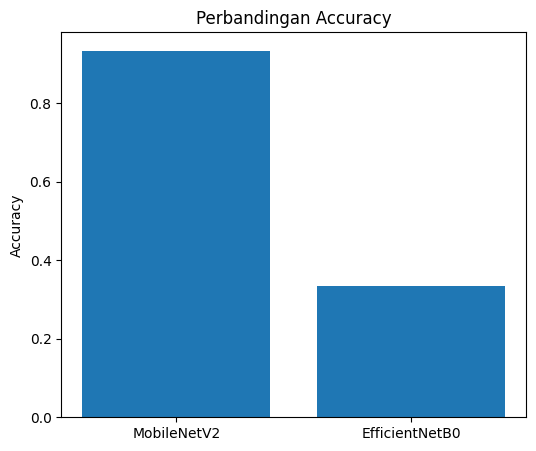

In [57]:
# ==========================================
# Grafik Perbandingan Accuracy
# ==========================================

plt.figure(figsize=(6,5))

plt.bar(
    hasil["Model"],
    hasil["Accuracy"]
)

plt.title("Perbandingan Accuracy")
plt.ylabel("Accuracy")

plt.show()

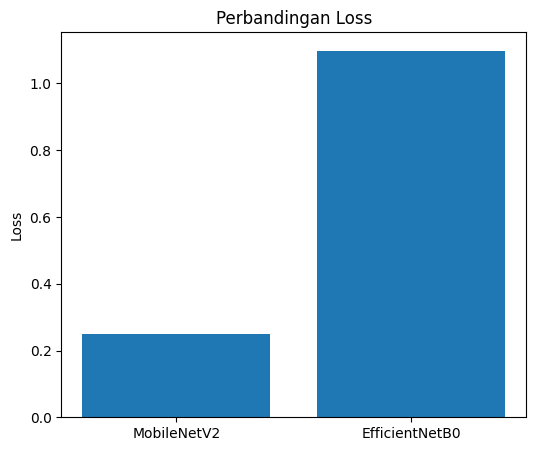

In [58]:
# ==========================================
# Grafik Perbandingan Loss
# ==========================================

plt.figure(figsize=(6,5))

plt.bar(
    hasil["Model"],
    hasil["Loss"]
)

plt.title("Perbandingan Loss")
plt.ylabel("Loss")

plt.show()

In [59]:
# ==========================================
# Menentukan Model Terbaik
# ==========================================

if acc1 > acc2:
    best_model = model1
    best_name = "MobileNetV2"
    best_acc = acc1
else:
    best_model = model2
    best_name = "EfficientNetB0"
    best_acc = acc2

print("="*45)
print("Model Terbaik")
print("="*45)
print(f"Model    : {best_name}")
print(f"Accuracy : {best_acc:.4f}")

Model Terbaik
Model    : MobileNetV2
Accuracy : 0.9333


In [60]:
# ==========================================
# Menyimpan Model Terbaik
# ==========================================

best_model.save("best_model.keras")

print("Model terbaik berhasil disimpan sebagai 'best_model.keras'")

Model terbaik berhasil disimpan sebagai 'best_model.keras'


In [80]:
# ==========================================
# Upload Gambar
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving download (1).jpg to download (1).jpg


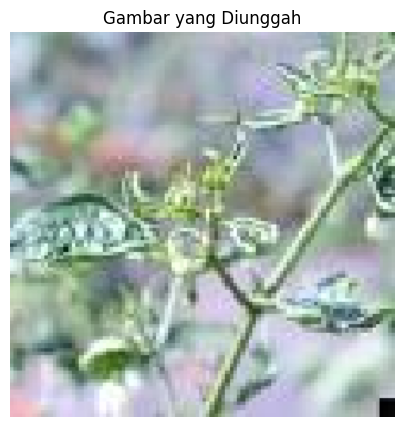

In [81]:
# ==========================================
# Menampilkan Gambar
# ==========================================

from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = load_img(image_path, target_size=(224,224))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Gambar yang Diunggah")
plt.axis("off")
plt.show()

In [82]:
# ==========================================
# Prediksi Gambar
# ==========================================

from tensorflow.keras.preprocessing.image import img_to_array
import numpy as np

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = best_model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("Prediksi selesai.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediksi selesai.


In [83]:
# ==========================================
# Hasil Prediksi
# ==========================================

kelas = list(train_data.class_indices.keys())

print("="*45)
print("HASIL PREDIKSI")
print("="*45)
print("Model          :", best_name)
print("Kelas Prediksi :", kelas[predicted_class])
print(f"Confidence     : {confidence:.2f}%")

HASIL PREDIKSI
Model          : MobileNetV2
Kelas Prediksi : leaf curl
Confidence     : 96.63%


In [84]:
# ==========================================
# Probabilitas Tiap Kelas
# ==========================================

print("="*45)

for i, nama in enumerate(kelas):
    print(f"{nama:15} : {prediction[0][i]*100:.2f}%")

healthy         : 1.70%
leaf curl       : 96.63%
leaf spot       : 1.67%


In [85]:
# ==========================================
# Menyimpan Hasil Evaluasi
# ==========================================

hasil.to_csv("hasil_perbandingan_model.csv", index=False)

print("Hasil perbandingan model berhasil disimpan.")

Hasil perbandingan model berhasil disimpan.


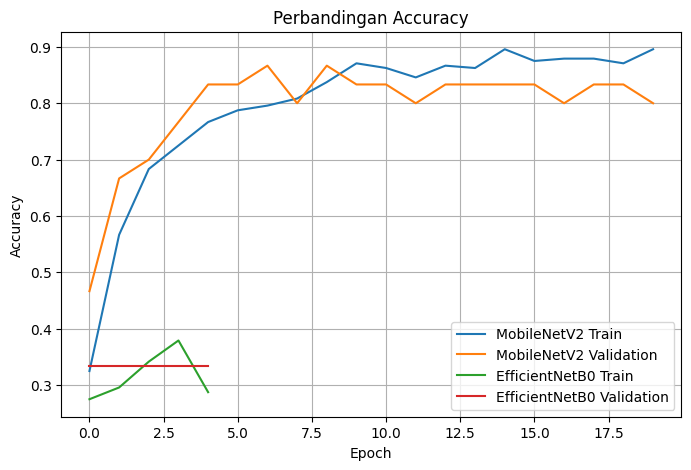

In [86]:
# ==========================================
# Simpan Grafik Accuracy
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history1.history['accuracy'], label='MobileNetV2 Train')
plt.plot(history1.history['val_accuracy'], label='MobileNetV2 Validation')

plt.plot(history2.history['accuracy'], label='EfficientNetB0 Train')
plt.plot(history2.history['val_accuracy'], label='EfficientNetB0 Validation')

plt.title("Perbandingan Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("accuracy_comparison.png", dpi=300)

plt.show()

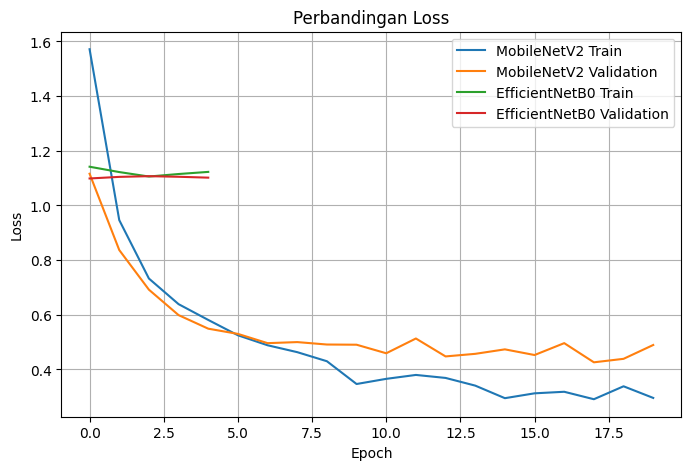

In [87]:
# ==========================================
# Simpan Grafik Loss
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history1.history['loss'], label='MobileNetV2 Train')
plt.plot(history1.history['val_loss'], label='MobileNetV2 Validation')

plt.plot(history2.history['loss'], label='EfficientNetB0 Train')
plt.plot(history2.history['val_loss'], label='EfficientNetB0 Validation')

plt.title("Perbandingan Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig("loss_comparison.png", dpi=300)

plt.show()

In [88]:
# ==========================================
# Simpan Classification Report
# ==========================================

from sklearn.metrics import classification_report

report1 = classification_report(
    y_true,
    y_pred1,
    target_names=class_names
)

report2 = classification_report(
    y_true,
    y_pred2,
    target_names=class_names
)

with open("classification_report.txt","w") as f:

    f.write("===== MobileNetV2 =====\n\n")
    f.write(report1)

    f.write("\n\n")

    f.write("===== EfficientNetB0 =====\n\n")
    f.write(report2)

print("Classification Report berhasil disimpan.")

Classification Report berhasil disimpan.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [89]:
# ==========================================
# Download Hasil
# ==========================================

from google.colab import files

files.download("best_model.keras")
files.download("hasil_perbandingan_model.csv")
files.download("classification_report.txt")
files.download("accuracy_comparison.png")
files.download("loss_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
# ==========================================
# Ringkasan Hasil Akhir
# ==========================================

print("="*60)
print("         RINGKASAN HASIL PENELITIAN")
print("="*60)

print(f"Jumlah Kelas        : {train_data.num_classes}")
print(f"Ukuran Gambar       : {IMG_SIZE}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Epoch               : {EPOCHS}")

print("="*60)

print(f"Accuracy MobileNetV2    : {acc1:.4f}")
print(f"Accuracy EfficientNetB0 : {acc2:.4f}")

print("="*60)

print(f"Model Terbaik : {best_name}")

print("="*60)

         RINGKASAN HASIL PENELITIAN
Jumlah Kelas        : 3
Ukuran Gambar       : (224, 224)
Batch Size          : 32
Epoch               : 20
Accuracy MobileNetV2    : 0.9333
Accuracy EfficientNetB0 : 0.3333
Model Terbaik : MobileNetV2
